In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

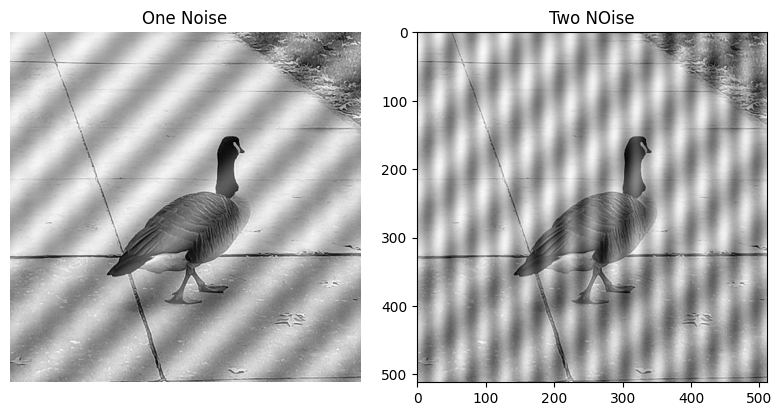

In [4]:
duck_Noise_1=cv2.imread("../test_assets/pnois2.jpg",0)
duck_Noise_2=cv2.imread("../test_assets/two_noise.jpeg",0)

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.title("One Noise")
plt.imshow(duck_Noise_1, cmap="gray")
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Two NOise")
plt.imshow(duck_Noise_2, cmap="gray")

plt.tight_layout()
plt.show()

In [5]:
# def ideal_notch_reject_filter(img,centers, radius):
#     H,W=img.shape
#     U,V=np.meshgrid(np.arange(W), np.arange(H))
#     M=np.ones((H,W), dtype=np.float32)

#     for center in centers:
#         u0,v0=center
#         Dk=np.sqrt((U-u0)**2+(V-v0)**2)
#         Dk_=np.sqrt((U-(W-u0))**2+(V-(H-v0))**2)
#         M=M*(Dk>radius)*(Dk_>radius)
#     return M
def ideal_notch_reject_filter(img,centers, radius):
    H,W=img.shape
    U,V=np.meshgrid(np.arange(W), np.arange(H))
    u_center=H//2
    v_center=W//2
    M=np.ones((H,W), dtype=np.float32)

    for center in centers:
        u0,v0=center
        uk=u0-u_center
        vk=v0-v_center
        Dk=np.sqrt((U-u_center-uk)**2+(V-v_center-vk)**2)
        Dk_=np.sqrt((U-u_center+uk)**2+(V-v_center+vk)**2)
        M=M*(Dk>radius)*(Dk_>radius)
    return M

In [6]:
def apply_idea_notch_reject_filter(img, centers, radius):
    ft=np.fft.fft2(img)
    ft_shift=np.fft.fftshift(ft)

    pow_ac=np.abs(ft_shift)
    pow_ac_log=20*np.log(pow_ac+1)
    pow_ac_norm=cv2.normalize(pow_ac_log,None,0,255,cv2.NORM_MINMAX, cv2.CV_8U)

    phase=np.angle(ft_shift)
    ph_=cv2.normalize(phase,None,0,255,cv2.NORM_MINMAX, cv2.CV_8U)

    ideal_notch=ideal_notch_reject_filter(img,centers,radius)

    filter=ft_shift*ideal_notch

    ft_shift_i=np.fft.ifftshift(filter)
    ft_i=np.fft.ifft2(ft_shift_i)
    filter_img=np.abs(ft_i)

    return pow_ac_norm,ph_,ideal_notch,filter,filter_img

In [7]:
centers=[(261,261)]
radius=5

pows,ph,notch,fil,fil_img=apply_idea_notch_reject_filter(duck_Noise_1, centers, radius)

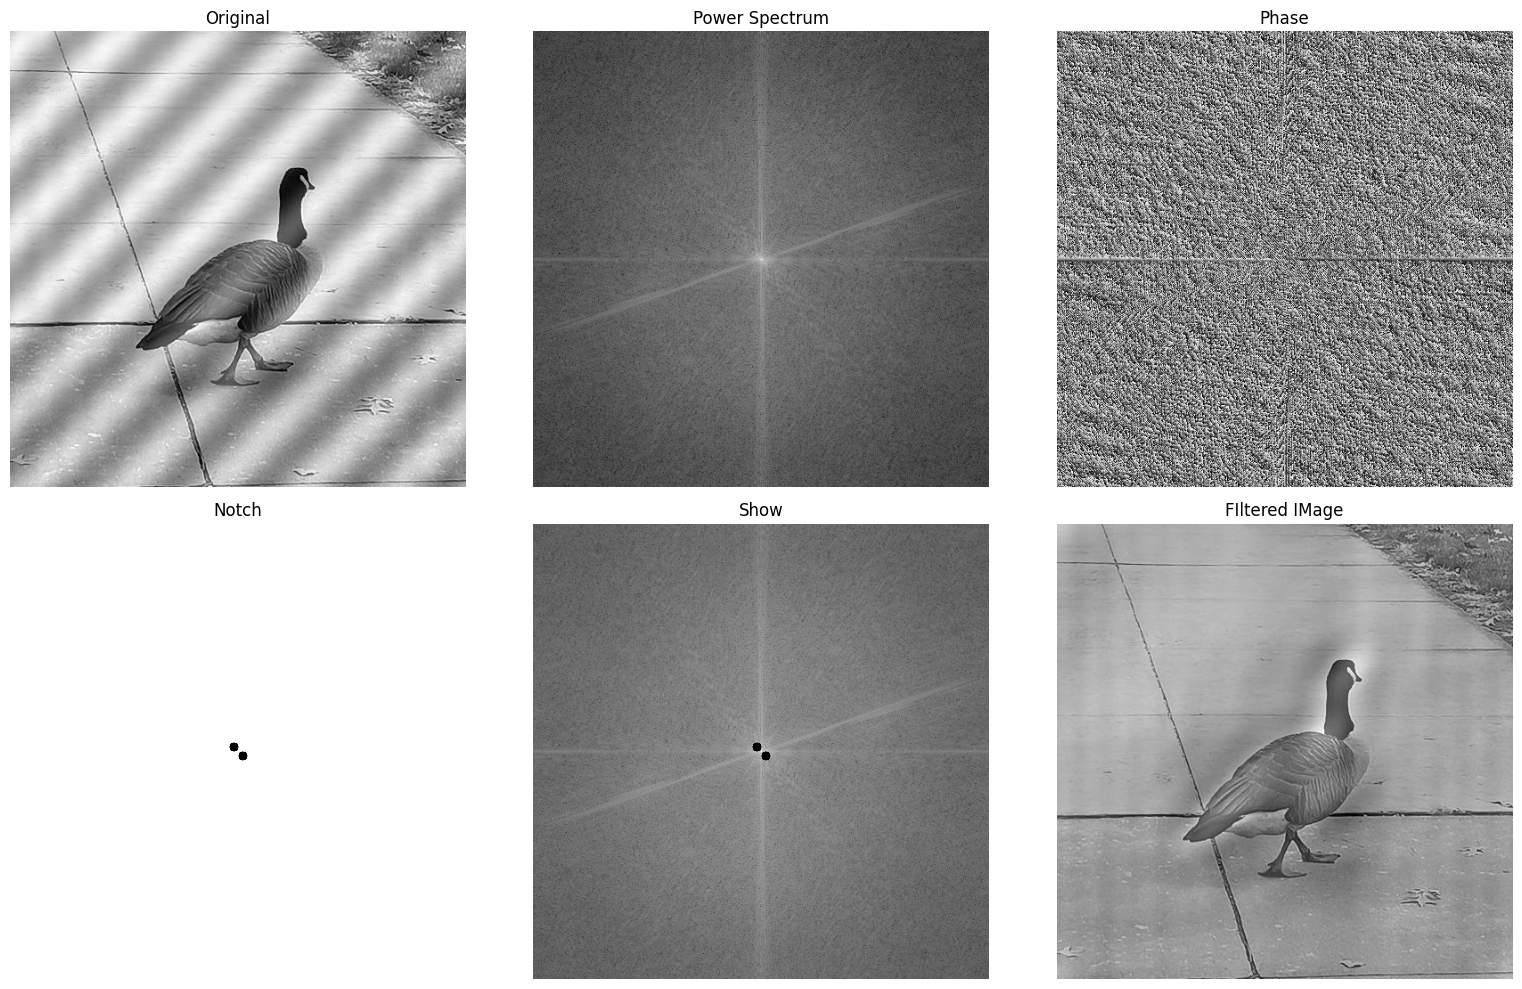

In [8]:
plt.figure(figsize=(16,10))

plt.subplot(2,3,1)
plt.title("Original")
plt.imshow(duck_Noise_1, cmap="gray")
plt.axis("off")

plt.subplot(2,3,2)
plt.title("Power Spectrum")
plt.imshow(pows, cmap="gray")
plt.axis("off")

plt.subplot(2,3,3)
plt.imshow(ph,cmap="gray")
plt.title("Phase")
plt.axis("off")

plt.subplot(2,3,4)
plt.title("Notch")
plt.imshow(notch, cmap="gray")
plt.axis("off")

shw=20*np.log(np.abs(fil)+1)
plt.subplot(2,3,5)
plt.title("Show")
plt.imshow(shw, cmap="gray")
plt.axis("off")

plt.subplot(2,3,6)
plt.title("FIltered IMage")
plt.imshow(fil_img, cmap="gray")
plt.axis("off")

plt.tight_layout()
plt.show()

In [9]:
def butte_reject(img, centers, D0, n):
    H,W=img.shape
    U,V=np.meshgrid(np.arange(W), np.arange(H))
    u_center=H//2
    v_center=W//2
    HN=np.ones((H,W), dtype=np.float32)
    eps=1e-6
    for center in centers:
        u0,v0=center
        uk=u0-u_center
        vk=v0-v_center
        Dk=np.sqrt((U-u_center-uk)**2+(V-v_center-vk)**2)+eps
        Dk_=np.sqrt((U-u_center+uk)**2+(V-v_center+vk)**2)+eps

        HDk=(D0/Dk)**(2*n)
        HDk_=(D0/Dk_)**(2*n)

        HNR=(1/(1+HDk))*(1/(1+HDk_))

        HN=HN*HNR
        
    return HN

In [10]:
def apply_butter(img, centers, D0, n):
    ft=np.fft.fft2(img)
    ft_shift=np.fft.fftshift(ft)

    power=np.abs(ft_shift)
    power_log=20*np.log(power+1)
    power_norm=cv2.normalize(power_log, None, 0, 255,cv2.NORM_MINMAX, cv2.CV_8U)

    phase=np.angle(ft_shift)
    phase_norm=cv2.normalize(phase,None, 0,255,cv2.NORM_MINMAX, cv2.CV_8U)

    butter_notch=butte_reject(img, centers,D0,n)

    fil=np.abs(ft_shift)*butter_notch
    fil = fil*np.exp(1j*np.angle(ft_shift))

    ft_shift_i=np.fft.ifftshift(fil)
    ft_i=np.fft.ifft2(ft_shift_i)
    back_img=np.abs(ft_i)

    return power_norm,phase_norm,butter_notch,fil,back_img

In [26]:
centers=[(272,256),(261,261)]
D0=5
n=2
pows,phs,bntch,fitt,backimg=apply_butter(duck_Noise_2,centers,D0,n)

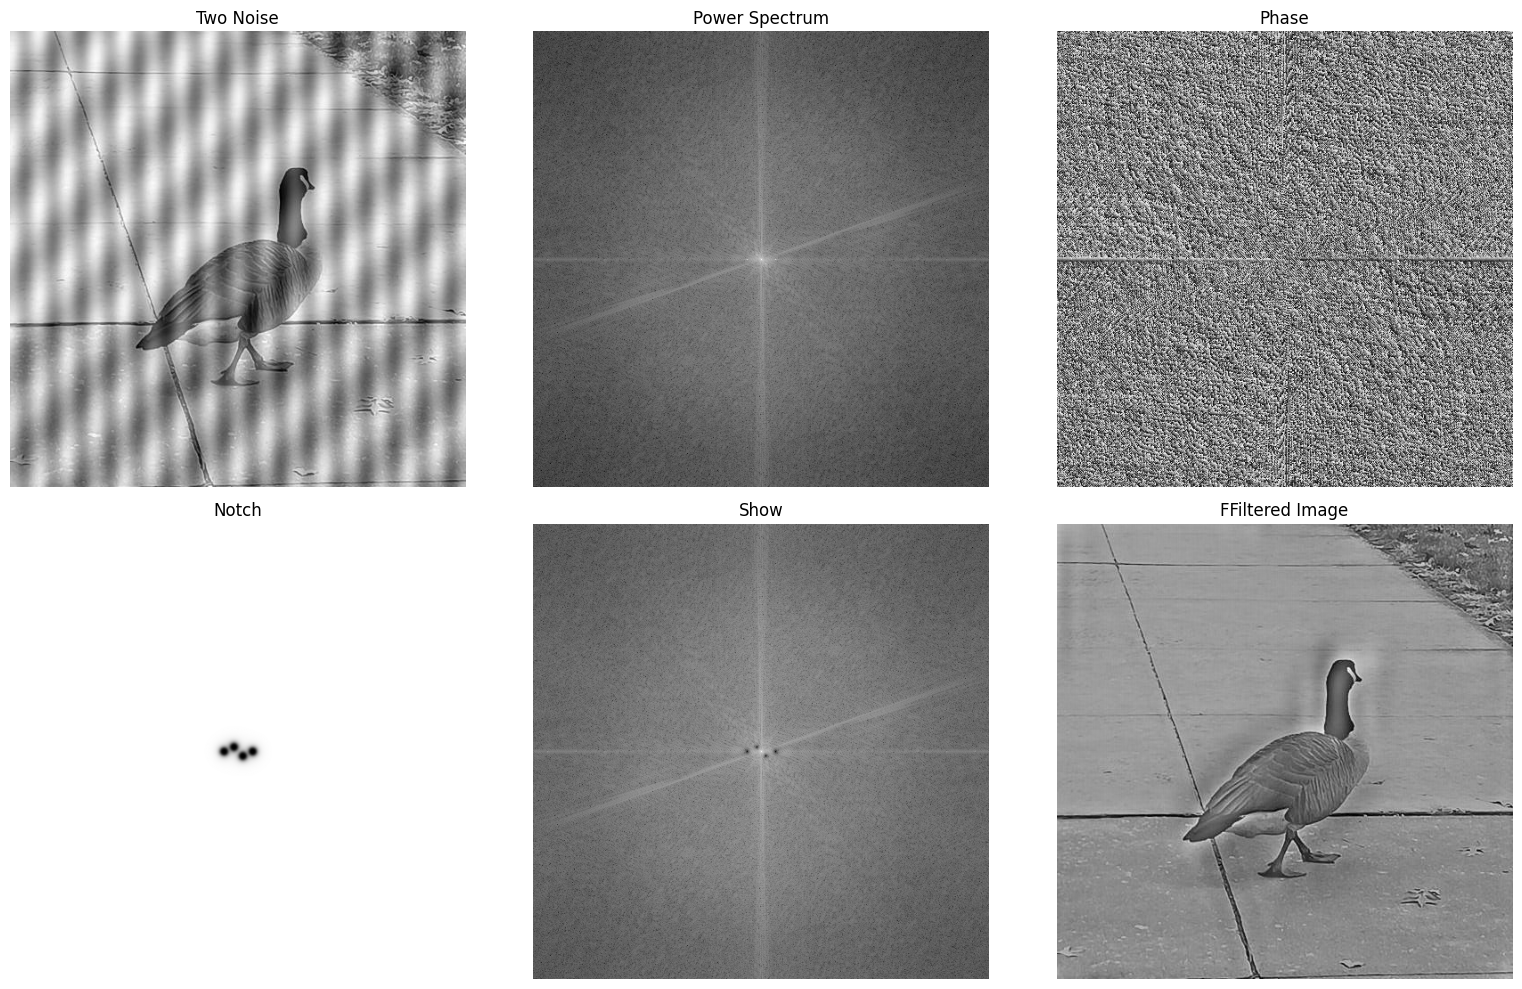

In [27]:
plt.figure(figsize=(16,10))

plt.subplot(2,3,1)
plt.title("Two Noise")
plt.imshow(duck_Noise_2, cmap="gray")
plt.axis("off")

plt.subplot(2,3,2)
plt.title("Power Spectrum")
plt.imshow(pows, cmap="gray")
plt.axis("off")

plt.subplot(2,3,3)
plt.imshow(phs,cmap="gray")
plt.title("Phase")
plt.axis("off")

plt.subplot(2,3,4)
plt.title("Notch")
plt.imshow(bntch, cmap="gray")
plt.axis("off")

shw=20*np.log(np.abs(fitt)+1)
plt.subplot(2,3,5)
plt.title("Show")
plt.imshow(shw, cmap="gray")
plt.axis("off")

plt.subplot(2,3,6)
plt.title("FFiltered Image")
plt.imshow(backimg, cmap="gray")
plt.axis("off")

plt.tight_layout()
plt.show()